In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import wbdata
import datetime 
import plotly.express as px 

In [8]:
# fetch data of world bank total population and gdp per capita for the  year ' '
import wbdata 
import pandas as pd 
 # Define the indicator for population ( sp.POP. Tptl)

indicator={
    'SP.POP.TOTL':'total_population'
} 

# Fetch Data 
data=wbdata.get_dataframe(indicator)

data.reset_index(inplace=True)
data.rename(columns={'country':'Country','date':'Year'},inplace=True)

data['Year']=pd.to_numeric(data['Year'])

df=data[(data['Year']<=2025) & (data['Year']>=1960)]
df.sample(5,random_state=42)


,Country,Year,total_population
2950,Sub-Saharan Africa (excluding high income),1999,597802260.0
16390,Ukraine,2014,45972380.0
4999,British Virgin Islands,1965,8257.0
1599,Latin America & Caribbean (excluding high income),1985,355849792.0
9575,Japan,2004,127761000.0


In [9]:
df.info()

<class 'wbdata.client.DataFrame'>
RangeIndex: 17290 entries, 0 to 17289
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           17290 non-null  object 
 1   Year              17290 non-null  int64  
 2   total_population  17195 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 405.4+ KB


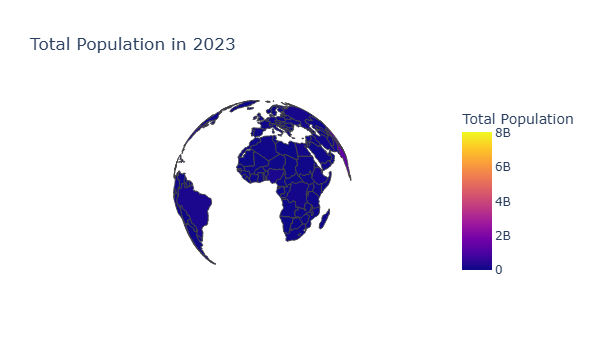

In [12]:
# make Choropleth map of total population using plotly 
fig=px.choropleth(df[df['Year']==2023 ], 
                 locations='Country', 
                  locationmode='country names', 
                  color='total_population', 
                  hover_name='Country', 
                  color_continuous_scale=px.colors.sequential.Plasma, 
                  title='Total Population in 2023', 
                  labels={'total_population':'Total Population'}
                 )
# limit the axis for total population 
fig.update_geos(
    visible=False,
    projection_type='orthographic'
)

fig.show()

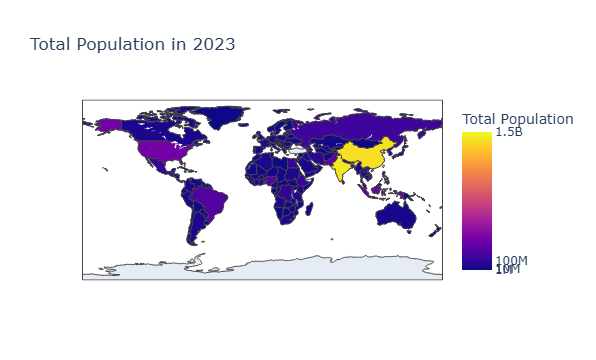

In [13]:
# make Choropleth map of total population using plotly 
fig=px.choropleth(df[df['Year']==2023 ], 
                 locations='Country', 
                  locationmode='country names', 
                  color='total_population', 
                  hover_name='Country', 
                  color_continuous_scale=px.colors.sequential.Plasma, 
                  title='Total Population in 2023', 
                  labels={'total_population':'Total Population'}
                 )
# limit the scale of the colorbar 
fig.update_layout(
    coloraxis_colorbar=dict(
        title='Total Population', 
        tickvals=[1e6,1e7,1e8,1.5e9], # Custom tick values
         ticktext=['1M','10M','100M','1.5B']
        
    ), 
    coloraxis=dict(
        cmin=0, 
        cmax=1.5e9
    )
)

fig.show()